# Évaluation des Modèles

In [1]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.evaluation.evaluator import TimeSeriesEvaluator
from src.models.prophet import ProphetRegressor
from src.models.fourier import FourierRegressor
from src.models.baselines import AverageRegressor, LastWeekRegressor, YesterdayRegressor, LinearRegressor, SimilarDayRegressor
from src.models.xgboost_regressor import XGBoostRegressor
from src.models.lstm_regressor import LSTMRegressor
from src.models.sarimax import SARIMAXRegressor

df = pd.read_csv('../data/processed/dataset_final.csv')

evaluator = TimeSeriesEvaluator(df, "perfect")

val_start = pd.to_datetime('2024-01-01').tz_localize('Europe/Paris')
test_start = pd.to_datetime('2025-01-01').tz_localize('Europe/Paris')

df_train, df_val, df_test = evaluator.split_data(val_start, test_start, load_existing_splits=True)

Importing plotly failed. Interactive plots will not work.


## Modèles de Références

In [2]:
# _, best_average = evaluator.grid_search_rolling_validation(AverageRegressor, [{}])
_, best_lastweek = evaluator.grid_search_rolling_validation(LastWeekRegressor, [{}])
_, best_yesterday = evaluator.grid_search_rolling_validation(YesterdayRegressor, [{}])
_, best_linear = evaluator.grid_search_rolling_validation(
    LinearRegressor,
    [{"features_cols": [
        [
		'consommation_mw_meme_heure_derniere_connue',
        'consommation_mw_derniere_connue',
		'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
		'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances',
	]
    ]}]
);

Grid Search de LastWeekRegressor :

Combination 1/1 : {}
Évaluation de LastWeekRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
Progression: 2024-07-31 00:00...
Train : MAE = 3603.92 MW |RMSE = 5263.99 MW |MAPE = 6.51%


Validation : MAE = 3229.23 MW |RMSE = 4845.62 MW |MAPE = 6.05%

Best MAE sur Validation : 3229.23 MW
Best Params : {}

Grid Search de YesterdayRegressor :

Combination 1/1 : {}
Évaluation de YesterdayRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
Progression: 2024-07-31 00:00...
Train : MAE = 3564.97 MW |RMSE = 4974.06 MW |MAPE = 6.88%


Validation : MAE = 3182.98 MW |RMSE = 4362.14 MW |MAPE = 6.40%

Best MAE sur Validation : 3182.98 MW
Best Params : {}

Grid Search de LinearRegressor :

Combination 1/1 : {'features_cols': ['consommation_mw_meme_heure_derniere_connue', 'consommation_mw_derniere_connue', 'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366', 'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'we

In [3]:
_, best_similar = evaluator.grid_search_rolling_validation(
    SimilarDayRegressor,
    {
		"k": [2],
		"temp_weight": [100.0]
	}
);

Grid Search de SimilarDayRegressor :

Combination 1/1 : {'k': 2, 'temp_weight': 100.0}
Évaluation de SimilarDayRegressor | 8784 lignes | réentraînement/6ME | 3 itérations


KeyboardInterrupt: 

## Fourier Regression

In [4]:
features_cols = [
    [
		'consommation_mw_meme_heure_derniere_connue',
        'consommation_mw_derniere_connue',
		'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
		'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances',
		'temperature_c_pondere_pop_meme_heure_derniere_connue',
		'temperature_c_pondere_pop_derniere_connue',
		'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366'
	]
]

_, best_fourier = evaluator.grid_search_rolling_validation(
    FourierRegressor,
    [
		{
			"features_cols": features_cols,
			"fourier_orders": [{'yearly': 15, 'weekly': 15, 'daily': 15}]
		},
	]
);

evaluator.rolling_test(best_lastweek["model"]);
evaluator.rolling_test(best_yesterday["model"]);
evaluator.rolling_test(best_linear["model"]);
evaluator.rolling_test(best_fourier["model"]);

Grid Search de FourierRegressor :

Combination 1/1 : {'features_cols': ['consommation_mw_meme_heure_derniere_connue', 'consommation_mw_derniere_connue', 'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366', 'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances', 'temperature_c_pondere_pop_meme_heure_derniere_connue', 'temperature_c_pondere_pop_derniere_connue', 'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366'], 'fourier_orders': {'yearly': 15, 'weekly': 15, 'daily': 15}}
Évaluation de FourierRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
Progression: 2024-07-31 00:00...
Train : MAE = 1546.10 MW |RMSE = 2058.15 MW |MAPE = 3.00%


Validation : MAE = 1481.97 MW |RMSE = 2000.97 MW |MAPE = 3.01%

Best MAE sur Validation : 1481.97 MW
Best Params : {'features_cols': ['consommation_mw_meme_heure_derniere_connue', 'consommation_mw_derniere_connue', 'consommation_mw_moins_7', 'consommation_mw_

# SARIMAX

In [ ]:
import itertools

p = [2]
d = [0, 1]
q = [2]
orders = list(itertools.product(p, d, q))

P = [1]
D = [1]
Q = [1]
seasonal_orders = [(*x, 24) for x in itertools.product(P, D, Q)]

_, best_sarimax = evaluator.grid_search_rolling_validation(SARIMAXRegressor, [
	{
		"order": orders,
		"seasonal_order": seasonal_orders,
		"features_cols": [[
			'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
			'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances',
			'temperature_c_pondere_pop_meme_heure_derniere_connue',
			'temperature_c_pondere_pop_derniere_connue',
			'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366'
		]],
		"since_year": [2023]
	}
], freq="12ME");

## Prophet

In [ ]:
_, best_prophet = evaluator.grid_search_rolling_validation(
    ProphetRegressor,
    [{"features_cols": [
        [
			"temperature_c_pondere_pop_sous_15_derniere_connue", "temperature_c_pondere_pop_au_dessus_22_derniere_connue",
        ]
    ]}]
);

## XGB

In [ ]:
_, best_xgb = evaluator.grid_search_rolling_validation(
    XGBoostRegressor,
    [{}]
);

# LSTM

In [ ]:
_, best_lstm = evaluator.grid_search_rolling_validation(
	LSTMRegressor,
	[{}],
	freq="15ME"
);

## Visualisation

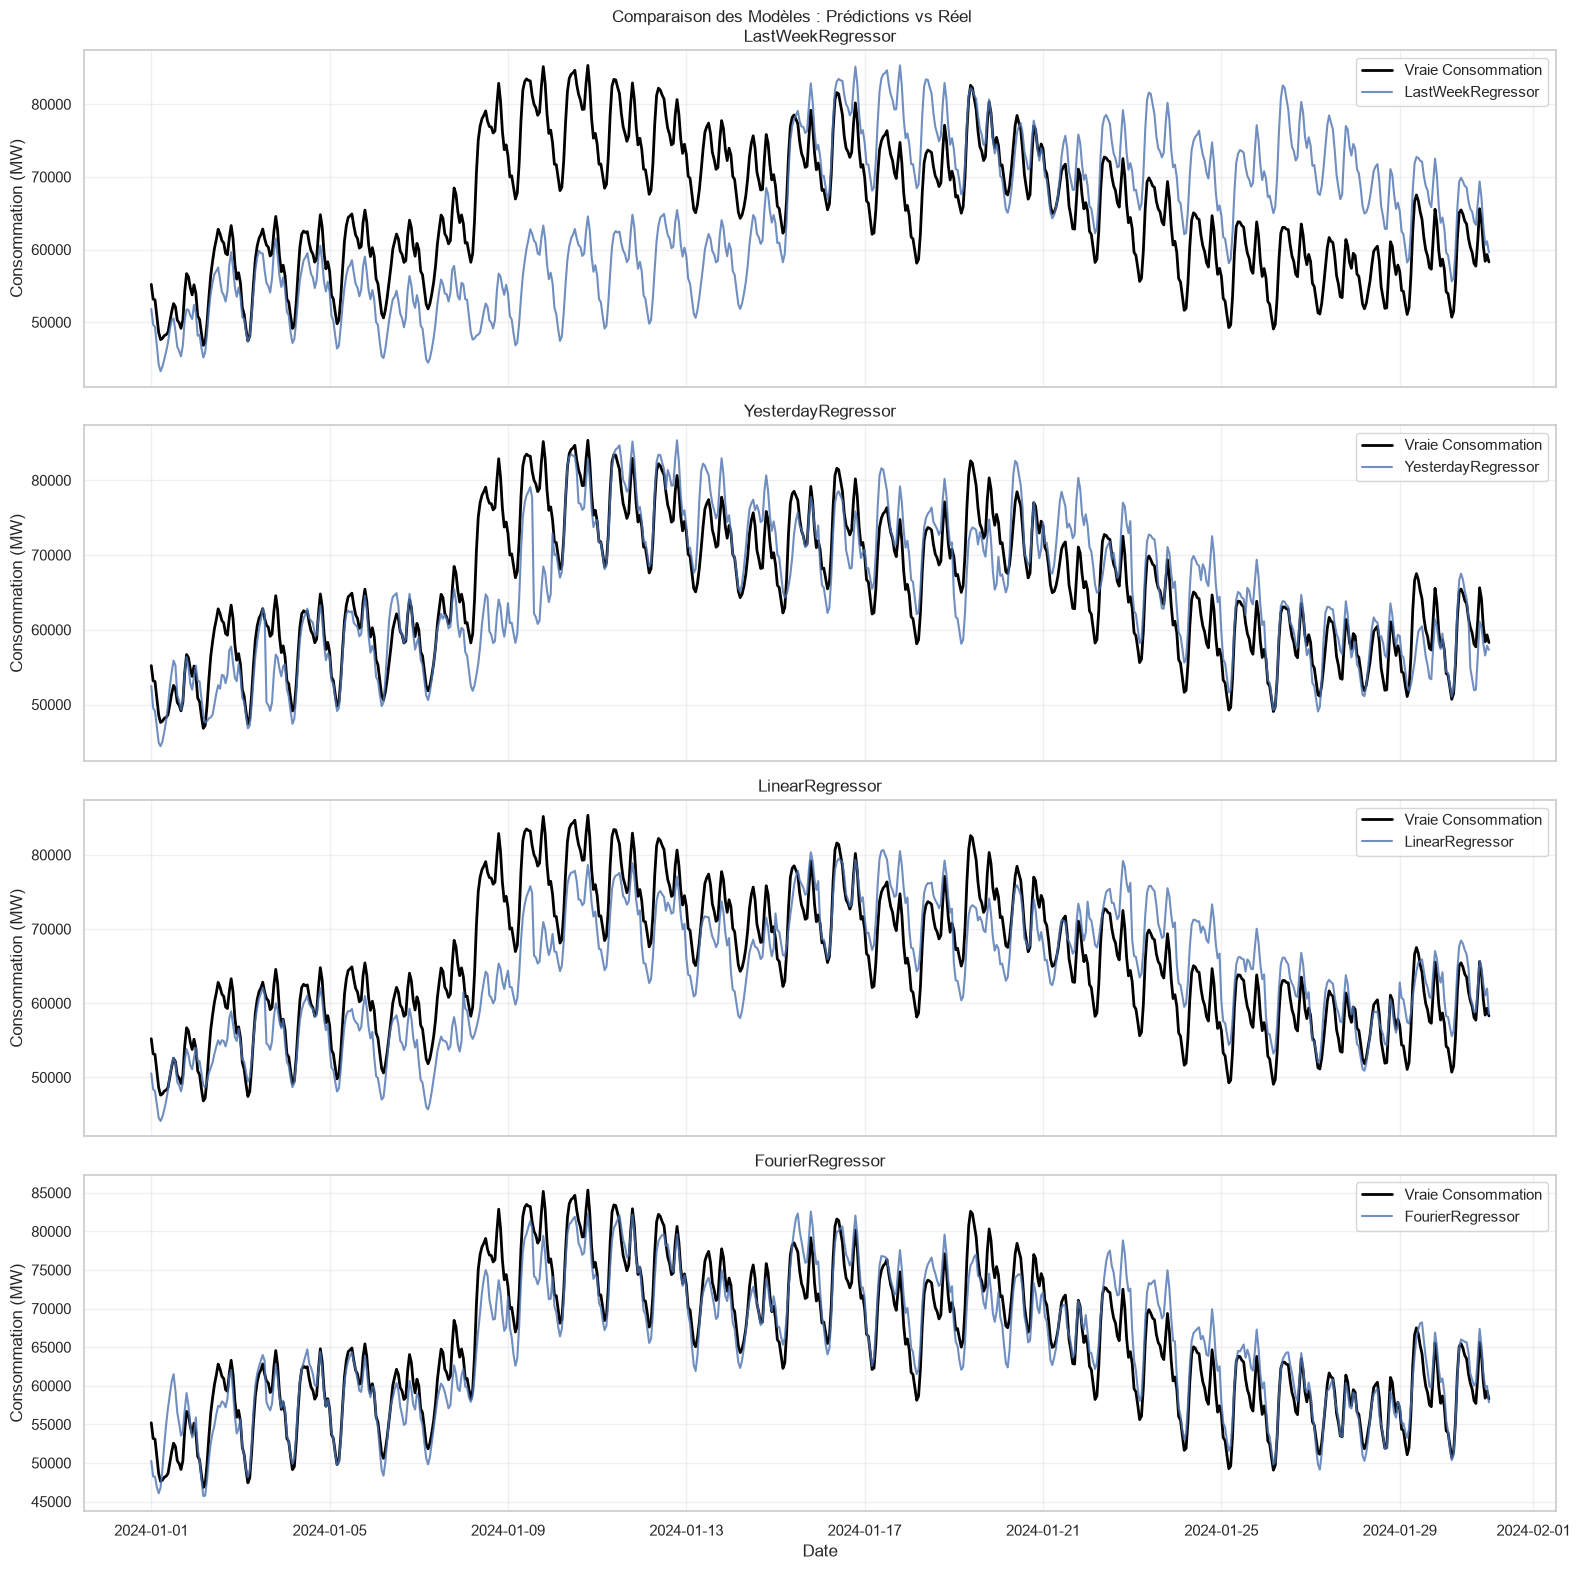

In [5]:
# Zoomons sur le mois de Janvier 2024
start_zoom = pd.to_datetime('2024-01-01').tz_localize('Europe/Paris')
end_zoom = pd.to_datetime('2024-01-31').tz_localize('Europe/Paris')

evaluator.plot_predictions(use_test=False, start_date=start_zoom, end_date=end_zoom)

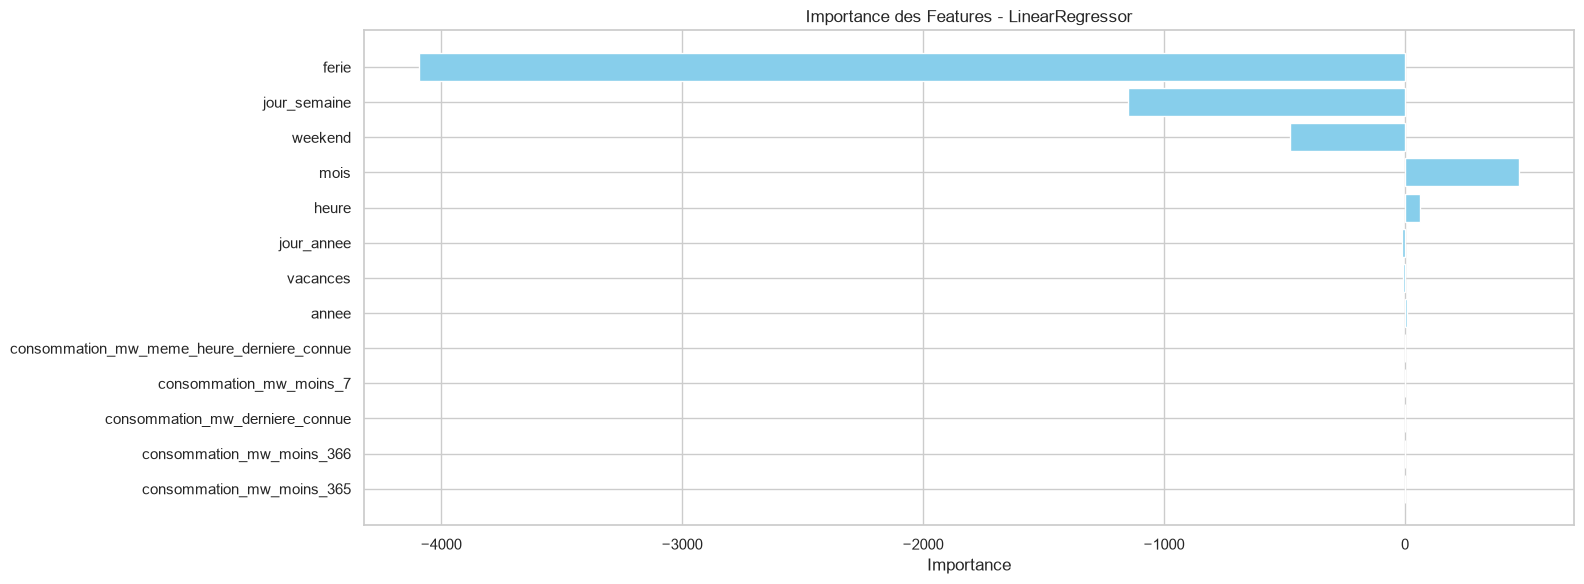

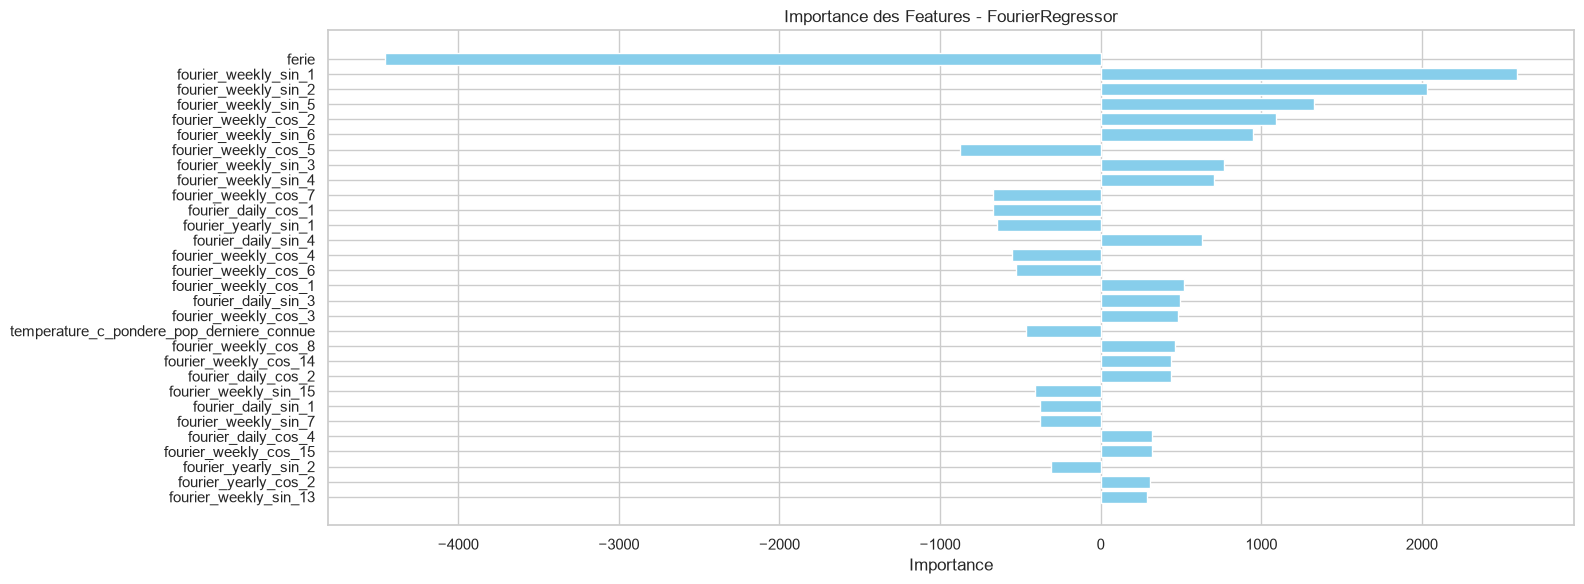

In [6]:
evaluator.plot_feature_importances(top_n=30)

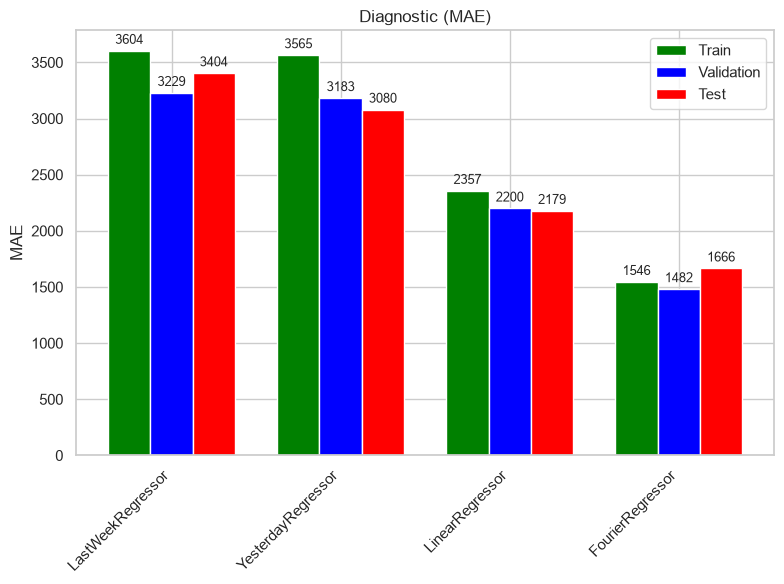

In [7]:
evaluator.plot_train_val_test_metrics()

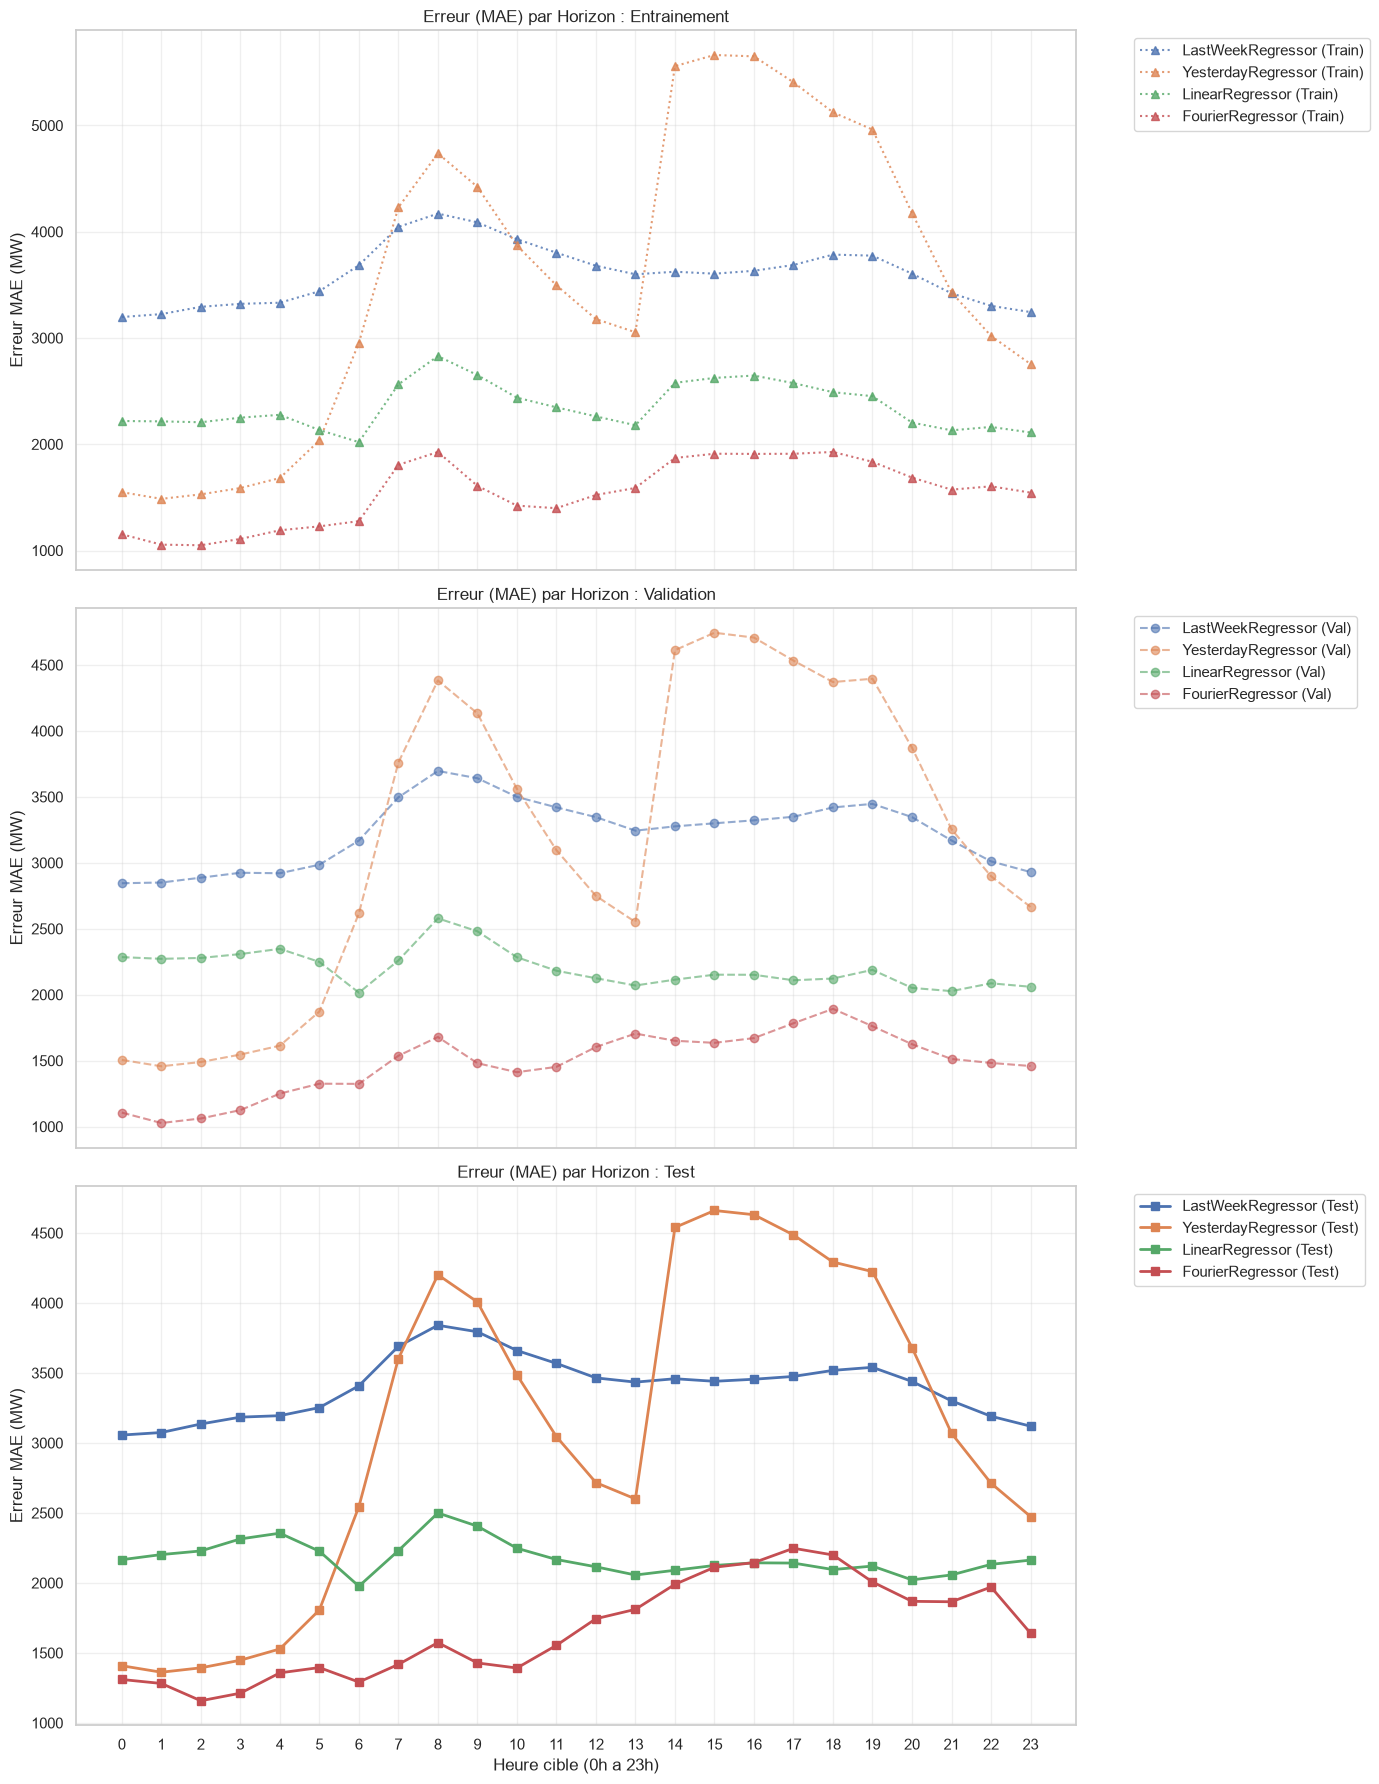

In [8]:
evaluator.plot_error_per_horizon()

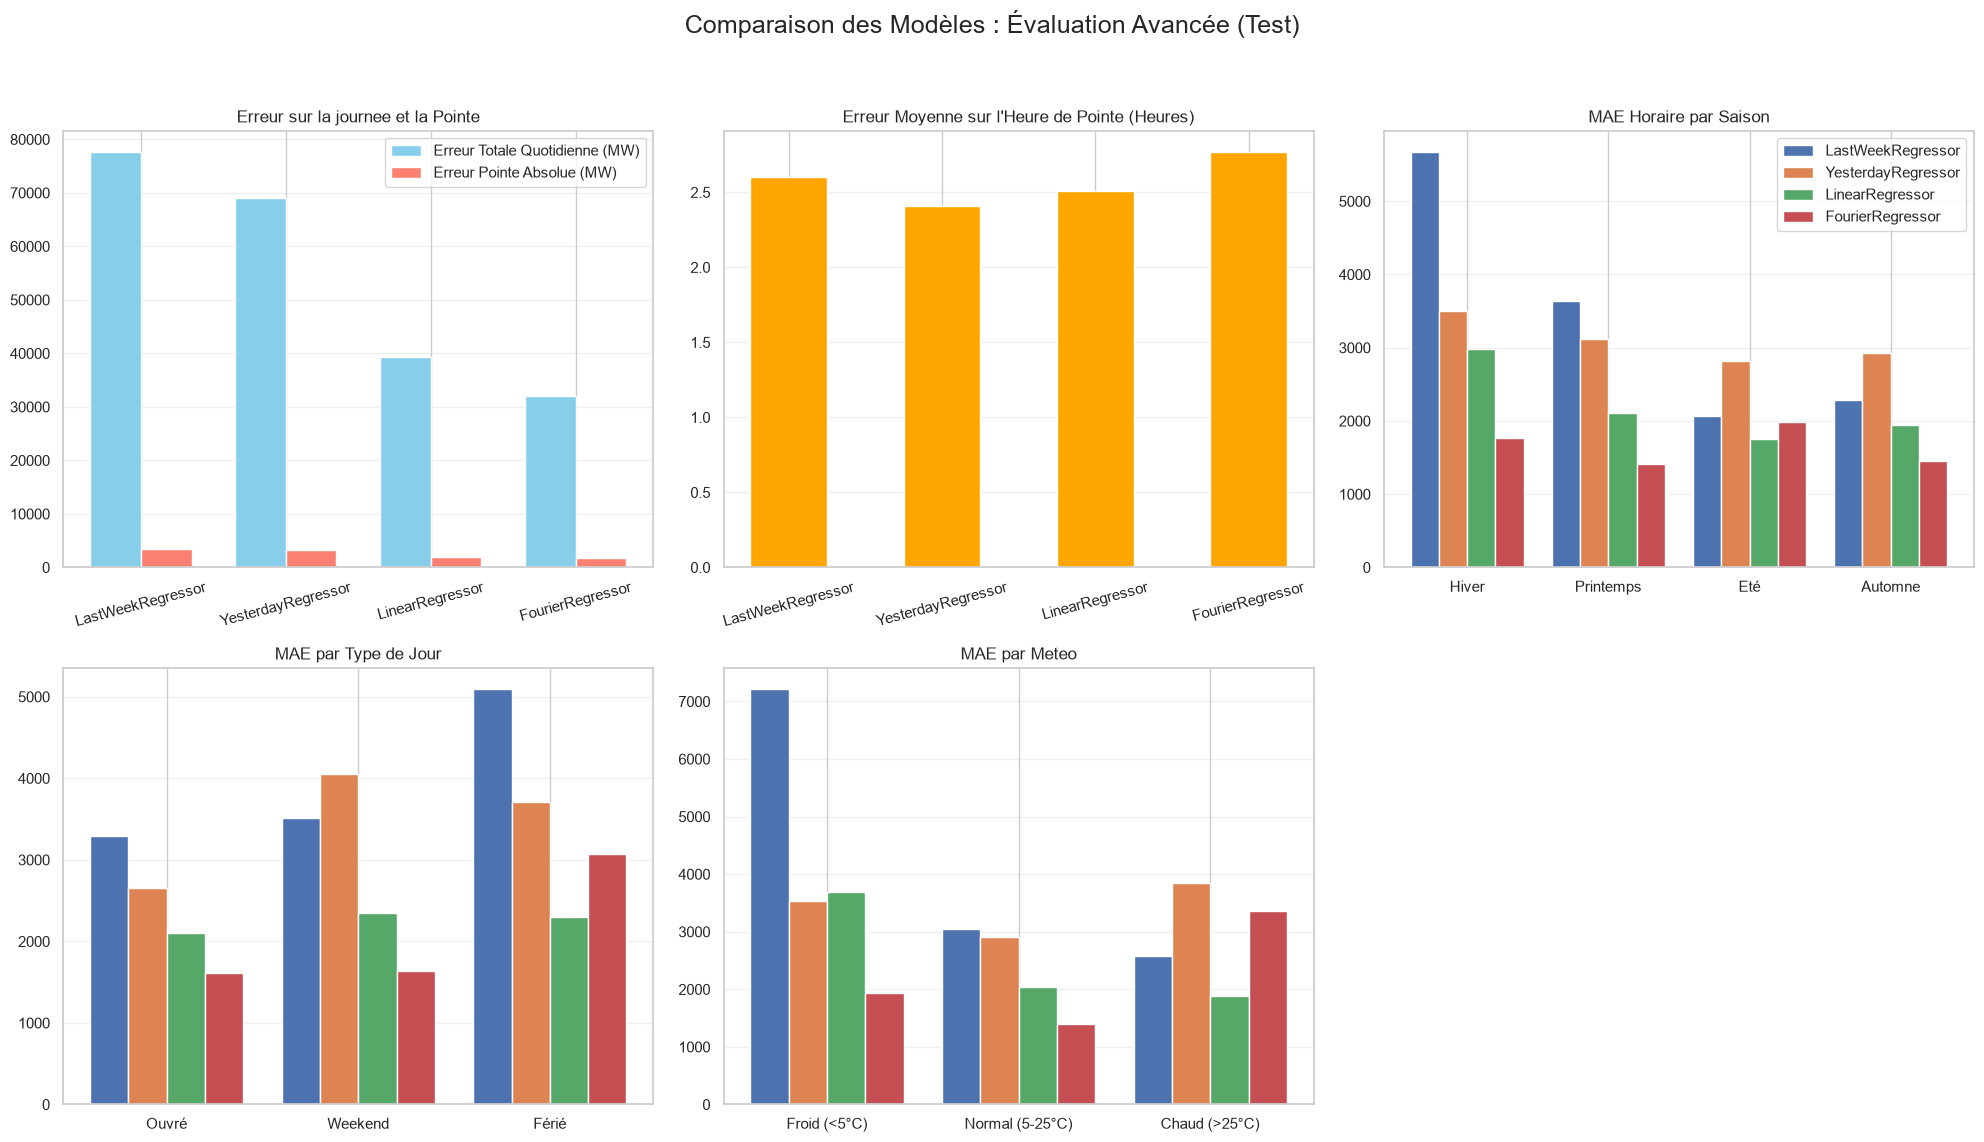

In [9]:
evaluator.plot_advanced_metrics()